# Module 1 — Event Instrumentation & the Semantic Layer

Part of the Product Analytics Playbook. Program and progress: [CURRICULUM.md](CURRICULUM.md).

## Why you're here: what this module is for

- Every number in this playbook (orders, revenue, active users, retention) is computed from one table: an **event log**, with one row for each thing a user did on the store's website.
- The log is written by the website's code, and that code can make mistakes. So before any number is trusted, the log has to be checked.
- Even on a correct log, a question like "how many orders?" can have more than one reasonable answer. If each person computes it their own way, two charts will show two different numbers.

**What this module produces:**
1. An audit of the real event log: every problem, counted.
2. A tracking plan: written rules for what a correct event looks like, and a check of every logged event against them.
3. A semantic layer: the cleaning rules and metric definitions, written once, that every later module uses.

## From the curriculum

> ## <u>Module 1 — Event Instrumentation & the Semantic Layer</u>
>
> **Concepts**
> - Events, properties and entities: what a product event log actually records,
>   and what it doesn't (here: no order id, no quantity, no signup event)
> - The tracking plan: one written set of rules per event (name, required
>   properties, types, allowed values), naming conventions (Object + Action), and
>   validating real events against it with JSON Schema (a standard format for
>   data rules that a program can check)
> - Instrumentation failure modes: duplicate firing, missing properties,
>   impossible values, events whose meaning is unclear
> - The semantic layer: metric definitions written once (entity, filter,
>   aggregation, time grain) and reused, so "revenue" or "active user" means the
>   same thing in every chart. Time grain = the period a metric is counted over
>   (day, month)
> - Why definitions change answers: the same question computed under two
>   reasonable definitions
>
> **Why it matters**
> Every metric in Modules 2–10 is only as good as the events beneath it and the
> definition on top. Two dashboards that disagree can be showing two definitions,
> not two realities. Defining the semantic layer for product event data is core
> analyst work: it decides what every downstream number means.
>
> **Worked example**
> An audit of the raw log, with every issue counted:
> - About 5% of rows are extra copies of another row, concentrated in
>   `remove_from_cart` (24.82% of those events in the sample) and `cart` (1.96%), against 0.06% for
>   purchases.
> - `category_code` is about 98% empty and `brand` about 42% empty.
> - There is no order id. An order is reconstructed as all purchase lines sharing
>   a user, session and timestamp.
>
> Then a tracking plan for the four events, the raw events validated against it,
> and a semantic layer (metric definitions plus SQLite views) built on the
> cleaned events. Finally, "how many orders / how much cart activity?" answered
> under raw vs. defined counting, showing the gap in numbers.
>
> **Resources**
> - [Data Collection Best Practices](https://www.twilio.com/docs/segment/protocols/tracking-plan/best-practices)
>   (Twilio Segment docs, ~15 min, verified): naming conventions, Object + Action,
>   why fewer events with richer properties.
> - [About MetricFlow](https://docs.getdbt.com/docs/build/about-metricflow)
>   (dbt docs, ~15 min, verified): how an industry semantic layer structures
>   semantic models and metrics. This module builds the same idea from scratch in
>   SQLite.
>
> **Exercise type:** design drills, fully worked: write the tracking-plan entry
> for a new event; diagnose which definition two disagreeing dashboards used.
>
> **Interview angle:** "How would you instrument feature X?" / "Two teams report
> different DAU (Daily Active Users) numbers. What do you do?"

## Lesson

### What an event log records

An **event** is one thing a user did, at one moment. In this store's log, each row records:

- **who**: `user_id`
- **when**: `event_time`, in UTC (Coordinated Universal Time, the standard reference clock), to the second
- **what**: `event_type`, one of four:
  - `view`: the user opened a product page
  - `cart`: the user added a product to the cart
  - `remove_from_cart`: the user removed a product from the cart
  - `purchase`: the user bought a product
- **which product**: `product_id`, `category_id`, `category_code`, `brand`, `price`
- **which visit**: `user_session`, an id the website gives to one visit

The columns that describe the event (product, brand, price, session) are its **properties**.

The things the business counts (users, sessions, products, orders) are **entities**. A good log lets you count every entity you need. This log has a gap: it has no order id, so nothing says which purchase rows belong to the same order. Part 1d rebuilds orders from the data.

### The tracking plan

A **tracking plan** is a written list of rules for what each event should look like:

- its **name**. The common convention is Object + Action: "Product Added to Cart", rather than "cart" or "add2cart_v2".
- its **properties**: which must always be present, what type each is (number, text), and which values are allowed (e.g. a price is never negative).

The plan can be written in **JSON Schema**, a standard format for data rules that a program checks automatically. Then every logged row is checked, and every **failure** (a row that breaks a rule) is found and tallied by rule.

Finding a failure does not decide what happens to the row. Whether it is deleted, set aside or kept is a separate decision, made per rule in the semantic layer (Part 3).

### How logging goes wrong

1. **Duplicates**: one action logged twice.
2. **Missing properties**: a field that should always be filled is empty.
3. **Impossible values**: e.g. a negative price on a purchase.
4. **Missing entities**: something the business counts (an order) that the log never records.
5. **Unclear meaning**: e.g. a "session" that lasts several days (Part 1e) is not what anyone means by one visit.

A schema check catches 2 and 3, because it looks at one row at a time. It cannot catch 1: each of two identical rows is a correct row on its own. Catching duplicates needs a check that compares rows with each other, or an `event_id` (a unique id per event) in the log.

### The semantic layer

A **semantic layer** is the set of definitions that sits between the raw log and every chart:

- **cleaning rules**: which rows count
- **entities**: e.g. what one order is
- **metrics**: what "revenue" or "active user" means, i.e. which rows, which filter, which calculation, over which period

Each definition is written **once**, in code, and every analysis uses it. In companies this is done with dedicated tools: dbt and Looker are two analytics products, and their semantic layers are called MetricFlow and LookML. This module builds the same idea from scratch, small enough to read in full:
- `semantic_layer/views.sql`: the cleaning rules and entities, written as SQL views (a view is a saved query that can be used like a table)
- `semantic_layer/metrics.json`: the metric definitions

Companies can split the semantic layer across tools: e.g. dbt holds the cleaning rules and entities (`views.sql` here) and Looker the metric definitions (`metrics.json` here). That works only if each definition has exactly one home. If the same metric is defined in both, the two versions drift apart (Part 4's problem).

### Why definitions change answers

"How many orders did we have?" sounds like it has one answer. On this log, counting purchase rows and counting orders give numbers about 8 times apart (Part 4). Neither is an arithmetic mistake: they answer different questions. Part 4 puts five such pairs side by side.

### Part 0 — The data, and what it doesn't record

**The sample:** all events of 10% of the store's users, October 2019 to February 2020. Each user is either fully in the sample or fully out. The users are picked by a fixed formula on `user_id` (`data/get_data.py`), so the sample is the same every time it is rebuilt.

**Counts are sample counts.** Every count in this playbook (events, users, orders, revenue) is for the sample. The whole store is roughly ten times larger. Rates and averages (shares, revenue per order) need no scaling.

Raw rows are not shown, because the data's licence does not allow republishing it. The table below summarises each column instead.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jsonschema

from common import load_events, connect, metric, metric_definitions, query, show, LAYER, BLUE, ORANGE, GREY

events = load_events()
print(f"events: {len(events):,}   users: {events['user_id'].nunique():,}   "
      f"sessions: {events['user_session'].nunique():,}")
print(f"time range (UTC): {events['event_time'].min()} to {events['event_time'].max()}")

events: 2,026,833   users: 164,270   sessions: 440,484
time range (UTC): 2019-10-01 00:01:17 to 2020-02-29 23:59:05


In [2]:
profile = pd.DataFrame({
    "type": events.dtypes.astype(str),
    "missing %": (events.isna().mean() * 100).round(2),
    "distinct values": events.nunique(),
})
print(profile.to_string())
print()
by_type = events["event_type"].value_counts()
print("events by type:")
print(pd.DataFrame({"events": by_type, "% of all": (by_type / len(events) * 100).round(2)}).to_string())

                         type  missing %  distinct values
event_time     datetime64[ns]       0.00          1636824
event_type           category       0.00                4
product_id              int64       0.00            45696
category_id             int64       0.00              503
category_code          string      98.32               11
brand                  string      41.98              268
price                 float64       0.00             2614
user_id                 int64       0.00           164270
user_session           string       0.03           440484

events by type:
                  events  % of all
event_type                        
view              956433     47.19
cart              562949     27.77
remove_from_cart  381628     18.83
purchase          125823      6.21


**Observation:** 2,026,833 events from 164,270 users. `category_code` is missing on 98.32% of rows and `brand` on 41.98%. `user_session` is missing on 0.03% of rows. 47.19% of events are views and 6.21% are purchases.

**Observation:** the log has no order id, no quantity, no currency, no device or platform, and no sign-up event. Any metric that needs one of these must either rebuild it from other columns or assume it. Each such assumption is written into the semantic layer and stated where it is used.

### Part 1 — Audit: every problem counted, before any metric

#### 1a. Duplicate rows

**Definitions used in this part:**
- A **duplicate row** is a row identical in **every** column to another row: same user, product, price, session and the same second.
- If a row appears N times, the first appearance is kept and the other N − 1 are its **extra copies**.
- **Removing duplicates** means deleting the extra copies, so each row appears once.

In [3]:
is_dup = events.duplicated(keep="first")
dups = pd.DataFrame({
    "rows": events.groupby("event_type", observed=True).size(),
    "extra copies": is_dup.groupby(events["event_type"], observed=True).sum(),
})
dups["extra copies %"] = (dups["extra copies"] / dups["rows"] * 100).round(2)
dups = dups.sort_values("extra copies %", ascending=False)
print(dups.to_string())
print(f"\nall types: {is_dup.sum():,} extra copies of {len(events):,} rows = {is_dup.mean():.2%}")
rem = dups.loc["remove_from_cart"]
kept = rem["rows"] - rem["extra copies"]
print(f"remove_from_cart: raw count / count after removing duplicates = {rem['rows']:,} / {kept:,} = {rem['rows'] / kept:.4f}, "
      f"i.e. raw is {(rem['rows'] / kept - 1):.2%} too high")

copies = events[events.duplicated(keep=False)].groupby(list(events.columns), dropna=False, observed=True).size()
appearances = copies.clip(upper=8).value_counts().sort_index()
appearances.index = [str(i) if i < 8 else "8 or more" for i in appearances.index]
print("\ndistinct rows that appear N times in total (N - 1 extra copies each):")
print(appearances.rename("distinct rows").to_string())
print(f"most appearances of a single row: {copies.max()}")

                    rows  extra copies  extra copies %
event_type                                            
remove_from_cart  381628         94735           24.82
cart              562949         11045            1.96
purchase          125823            78            0.06
view              956433           126            0.01

all types: 105,984 extra copies of 2,026,833 rows = 5.23%
remove_from_cart: raw count / count after removing duplicates = 381,628.0 / 286,893.0 = 1.3302, i.e. raw is 33.02% too high



distinct rows that appear N times in total (N - 1 extra copies each):
2            96318
3             1999
4              710
5              264
6              138
7               92
8 or more      116
most appearances of a single row: 48


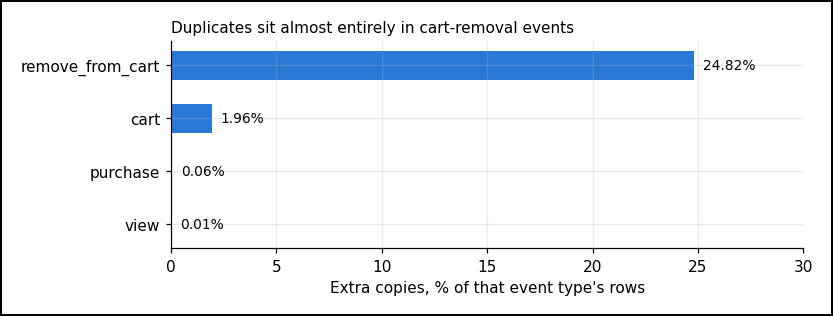

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 2.8))
ax.barh(dups.index[::-1], dups["extra copies %"][::-1], color=BLUE, height=0.55)
for y, v in enumerate(dups["extra copies %"][::-1]):
    ax.text(v + 0.4, y, f"{v:.2f}%", va="center", fontsize=9)
ax.set_xlabel("Extra copies, % of that event type's rows")
ax.set_title("Duplicates sit almost entirely in cart-removal events", fontsize=10, loc="left")
ax.set_xlim(0, 30)
plt.tight_layout(); plt.show()

**Observation:** 105,984 rows (5.23% of all rows) are extra copies. They are concentrated in `remove_from_cart` (24.82% of those rows) and `cart` (1.96%). Purchases (0.06%) and views (0.01%) have almost none. Most duplicated rows appear exactly twice (96,318 rows). One row appears 48 times.

How much this inflates removals: 24.82% of raw removal rows are extra copies. So the raw removal count is 1.3302 times the count after removing duplicates, i.e. 33.02% too high.

**Two possible explanations for the duplicates:**
- **(A) A logging error:** the website's code sent the same event twice.
- **(B) Multi-unit removals:** the log has no quantity column. If a user removed 3 units of one product, the website might log 3 identical removal rows. Then the duplicates would be real actions, not errors.

**Two checks follow.** Check 1 measures how reliable removals are at all; check 2 tests the two explanations.

1. **Is something ever removed that wasn't in the cart?** Look at **(user, product) pairs**: one user's cart events for one product. Go through each pair's events in time order and keep a **running count**: +1 for each add, −1 for each removal. If the running count drops below zero, the log shows a removal of a product that, according to the log, wasn't in the cart. If every row were a real action and every add happened inside the data's five months, this would never happen. Events in the same second are counted adds first, so a tie never creates a drop. The table shows how often the running count goes below zero at some point, and how often it is still below zero at the end of the data.
2. **Do duplicated removals look like multi-unit removals?** A **duplicated removal** is a removal row that appears more than once; a **single removal** appears once. If (B) were true, duplicated removals should come after *more* adds of that product (same user, same session) than single removals do.

In [5]:
def removal_balance(df):
    """Per (user, product): running adds minus removals over time. Adds count first within the same second."""
    c = df[df["event_type"].isin(["cart", "remove_from_cart"])].assign(
        step=lambda d: np.where(d["event_type"] == "cart", 1, -1))
    c = c.sort_values(["user_id", "product_id", "event_time", "step"], ascending=[True, True, True, False])
    bal = c.groupby(["user_id", "product_id"])["step"].cumsum().groupby([c["user_id"], c["product_id"]])
    return (bal.min() < 0).mean(), (bal.last() < 0).mean(), bal.ngroups

first_seen = events.groupby("user_id")["event_time"].min()
dec_users = first_seen[first_seen >= "2019-12-01"].index
jan_users = first_seen[first_seen >= "2020-01-01"].index
clean_copy = events.drop_duplicates()
for label, df in [("raw log", events), ("duplicates removed", clean_copy),
                  ("duplicates removed, only users first seen from Dec 2019", clean_copy[clean_copy["user_id"].isin(dec_users)]),
                  ("duplicates removed, only users first seen from Jan 2020", clean_copy[clean_copy["user_id"].isin(jan_users)])]:
    ever, total, pairs = removal_balance(df)
    print(f"{label:57s} pairs: {pairs:>7,}   running count below zero: at some point {ever:.2%}, at the end {total:.2%}")
# Multi-unit test: if N identical removal rows meant "removed N units", duplicated removals
# should follow more adds of that product (same user, same session) than single removals do.
removals = events[events["event_type"] == "remove_from_cart"]
times = removals.groupby(list(events.columns), dropna=False, observed=True).size().rename("appearances").reset_index()
adds = (events[events["event_type"] == "cart"].drop_duplicates()
        .groupby(["user_id", "user_session", "product_id"]).size().rename("adds"))
times = times.join(adds, on=["user_id", "user_session", "product_id"]).fillna({"adds": 0})
times["kind"] = np.where(times["appearances"] > 1, "duplicated removal", "single removal")
print("\nremovals vs. adds of the same product in the same session:")
print(times.groupby("kind").agg(removals=("adds", "size"),
                               share_with_2plus_adds=("adds", lambda a: round((a >= 2).mean() * 100, 2)),
                               share_with_no_add=("adds", lambda a: round((a == 0).mean() * 100, 2))).to_string())

raw log                                                   pairs: 468,107   running count below zero: at some point 25.76%, at the end 24.81%


duplicates removed                                        pairs: 468,107   running count below zero: at some point 11.41%, at the end 10.86%


duplicates removed, only users first seen from Dec 2019   pairs: 159,596   running count below zero: at some point 8.09%, at the end 7.73%
duplicates removed, only users first seen from Jan 2020   pairs: 102,989   running count below zero: at some point 7.73%, at the end 7.35%



removals vs. adds of the same product in the same session:
                    removals  share_with_2plus_adds  share_with_no_add
kind                                                                  
duplicated removal     90743                   5.28              61.54
single removal        196150                  11.87              55.89


**Observation, check 1:** in the raw log, the running count drops below zero for 25.76% of (user, product) pairs. After removing duplicates, 11.41%. (Removing duplicates is bound to lower this number, because the duplicates are mostly removals.)

**Observation, check 2:** duplicated removals come after 2 or more adds in 5.28% of cases, against 11.87% for single removals. They also more often have no add at all in the same session (61.54% vs. 55.89%).

**Conclusion: the cause of the duplicates is unknown.**
- (B), multi-unit removals, predicts that duplicated removals come after *more* adds. They come after fewer, so (B) is unlikely.
- (A), a logging error, is not settled either way. If the error picked removals at random to log twice, duplicated removals would come after 2+ adds as often as single removals do. They don't (5.28% vs. 11.87%), so the error is not random. An error that happens only in certain situations is still possible.

An `event_id` and a quantity column in the log would settle it.

**Rule 1 of the semantic layer: remove duplicates.** This is a chosen rule, because the cause is unknown. If some duplicates were real actions, the cost is undercounting removals, an event that is unreliable anyway (next paragraph).

**Open question: removals are unreliable even after removing duplicates.** The running count still drops below zero for 11.41% of pairs. One possible reason: the matching add happened before October 2019, outside the data. To test that, the last two lines of the table keep only users whose first event in the data is in December 2019 or later (8.09%), or January 2020 or later (7.73%). These users had no events in the first two (or three) months, so an earlier add is less likely to be hiding. The share falls from 11.41% to 8.09% (7.73%), but most of it remains, so missing earlier adds explain only part of the problem. `remove_from_cart` is therefore treated as unreliable: the `cart_removals` metric carries that warning, and no later module draws a conclusion from removals.

#### 1b. Missing values

In [6]:
brand_missing = events["brand"].isna().groupby(events["event_type"], observed=True).mean() * 100
brand_missing.loc["all types"] = events["brand"].isna().mean() * 100
print("brand missing, % of rows:")
print(brand_missing.round(2).to_string())
print(f"rows with a brand: {events['brand'].notna().mean():.2%} (= 100% - {events['brand'].isna().mean():.2%})")
per_product = events.groupby("product_id")["brand"].agg(lambda b: b.notna().mean())
print(f"\nproducts by brand ({len(per_product):,} products):")
for label, mask in [("brand on all their rows:", per_product == 1), ("brand missing on all rows:", per_product == 0),
                    ("brand on some rows only:", (per_product > 0) & (per_product < 1))]:
    print(f"  {label:28s} {int(mask.sum()):>6,} ({mask.mean():6.2%})")
print(f"\ncategory_code missing: {events['category_code'].isna().mean():.2%}")
print(f"user_session missing:  {events['user_session'].isna().sum():,} rows")

brand missing, % of rows:
event_type
cart                42.88
purchase            42.25
remove_from_cart    43.39
view                40.86
all types           41.98


rows with a brand: 58.02% (= 100% - 41.98%)



products by brand (45,696 products):
  brand on all their rows:     23,981 (52.48%)
  brand missing on all rows:   19,739 (43.20%)
  brand on some rows only:      1,976 ( 4.32%)

category_code missing: 98.32%
user_session missing:  628 rows


**Observation:** `brand` is missing on 40.86% to 43.39% of rows, for every event type alike (41.98% overall). Of 45,696 products, 52.48% have a brand on all their rows and 43.20% on none. Only 1,976 (4.32%) have it on some rows and not others.

**Conclusion:** the missing brands mostly come from the products themselves (some products have no brand recorded), not from one event type's logging. `category_code` is missing on 98.32% of rows and is not used. `category_id` is never missing and is used instead. No rows are removed for a missing brand. Any brand analysis covers only the 58.02% of rows that have one, and must say so.

#### 1c. Prices

In [7]:
neg = events[events["price"] < 0]
print(f"negative price: {len(neg)} rows, types {neg['event_type'].astype(str).value_counts().to_dict()}, "
      f"total {neg['price'].sum():.2f}")
zero = events[events["price"] == 0]
month = events["event_time"].dt.strftime("%Y-%m")
zero_table = zero.groupby([month[zero.index], "event_type"], observed=True).size().unstack(fill_value=0)
zero_table.index.name = "month"
print(f"\nzero price: {len(zero):,} rows (none are purchases). By month and type:")
print(zero_table.to_string())

negative price: 14 rows, types {'purchase': 14}, total -484.15



zero price: 7,166 rows (none are purchases). By month and type:
event_type  cart  remove_from_cart  view
month                                   
2019-10       70                27   404
2019-11      310                81   463
2019-12      122                48   494
2020-01      156                37   428
2020-02     2886              1248   392


**Observation:** 14 rows have a negative price, all of them purchases, totalling −484.15. 7,166 rows have a price of exactly 0, none of them purchases. Zero-price cart events jump in February 2020: 2,886, against 70 to 310 in each earlier month.

**Hypothesis:** the negative purchase rows are refunds logged as purchases. The log has no refund event to confirm it, so they are called **refund candidates**.

**Rule 2 of the semantic layer: set refund candidates aside.** They are moved to their own table (`refund_candidates`) instead of being deleted. Revenue can then be reported two ways (Part 4): **gross revenue** (refund candidates left out) and **net revenue** (refund candidates subtracted). Zero prices are kept, because a price of 0 is not impossible.

**Carried forward:** the cause of the February zero-price jump is unknown. It is left as it is here, and is the first case worked in Module 10, where diagnosing an unusual number starts with checking the logging.

In [8]:
clean_prices = events.drop_duplicates().query("price >= 0").assign(day=lambda d: d["event_time"].dt.date)
results = {}
for label, d in [("all", clean_prices), ("purchases", clean_prices[clean_prices["event_type"] == "purchase"])]:
    g = d.groupby(["product_id", "day"])["price"].agg(["nunique", "min", "max"])
    multi = g[g["nunique"] > 1]
    ratio = (multi["max"] / multi["min"].replace(0, np.nan)).dropna()
    whole = ((ratio >= 1.99) & ((ratio - ratio.round()).abs() < 0.01)).sum()
    results[label] = (len(multi), len(g), ratio.median() - 1, int(whole), len(ratio))
a, p = results["all"], results["purchases"]
print("is price a per-unit price or a line total? (same product, same day)")
print(f"  product-days with more than one price: {a[0]:,} of {a[1]:,} ({a[0]/a[1]:.2%}); "
      f"purchases only: {p[0]:,} of {p[1]:,} ({p[0]/p[1]:.2%})")
print(f"  typical gap between the higher and lower price: {a[2]:.0%} (purchases: {p[2]:.0%})")
print(f"  higher price an exact 2x, 3x... of the lower: {a[3]:,} of {a[4]:,} ({a[3]/a[4]:.2%}); "
      f"purchases only: {p[3]} of {p[4]} ({p[3]/p[4]:.2%})")

is price a per-unit price or a line total? (same product, same day)
  product-days with more than one price: 3,487 of 813,020 (0.43%); purchases only: 114 of 110,778 (0.10%)
  typical gap between the higher and lower price: 11% (purchases: 8%)
  higher price an exact 2x, 3x... of the lower: 31 of 2,217 (1.40%); purchases only: 1 of 114 (0.88%)


**Is `price` per unit, or the total for a line?** The log has no quantity, so two tests:
1. **Rule-out test:** if `price` were a fixed per-unit price, one product would have one price per day. It doesn't always: 0.43% of product-days have more than one price. But the differences are small (typically 11%), like a price change or discount.
2. **Multiple test:** if `price` were a line total, a product bought as 2 or 3 units would show 2× or 3× its usual price. That almost never happens: of the 114 purchase product-days with more than one price (out of 110,778), only 1 shows an exact multiple.

**Conclusion:** `price` behaves like a per-unit price that occasionally changes within a day. It is treated as a per-unit price.

#### 1d. Rebuilding orders

The log has no order id. It records **purchase lines**: one row per product bought. The rule used to rebuild orders: **all purchase lines with the same user, the same session and the same second form one order.**

**The check below: could one order be split into two?** That would show as two groups from the same user only seconds apart. Gaps of 2, 5 and 60 seconds are tested (chosen examples, deliberately generous).

In [9]:
buys = events[(events["event_type"] == "purchase") & (events["price"] >= 0)].drop_duplicates()
per_ts = buys.groupby(["user_id", "user_session", "event_time"]).size()
print(f"purchase lines: {len(buys):,}   distinct (user, session, second) groups: {len(per_ts):,}")
print(f"lines per group: average {per_ts.mean():.2f}; half of the groups have {per_ts.median():.0f} or fewer, "
      f"99% have {per_ts.quantile(0.99):.0f} or fewer; the largest has {per_ts.max()}")

groups = per_ts.reset_index().sort_values(["user_session", "event_time"])
gap = groups.groupby("user_session")["event_time"].diff().dt.total_seconds().dropna()
print(f"\ngroups beyond the first in their session: {groups['user_session'].duplicated().sum():,}")
print(f"gap between groups in the same session: median {gap.median():,.0f} s")
by_user = per_ts.reset_index().sort_values(["user_id", "event_time"])
user_gap = by_user.groupby("user_id")["event_time"].diff().dt.total_seconds()
same_session = by_user["user_session"].eq(by_user.groupby("user_id")["user_session"].shift())
for t in (2, 5, 60):
    print(f"  groups within {t:>2} s of the same user's previous group: "
          f"{int(((user_gap <= t) & same_session).sum())} in the same session, "
          f"{int(((user_gap <= t) & ~same_session).sum())} in a different session")
alt = buys.groupby(["user_id", "user_session"]).ngroups
print(f"alternative rule, one order per (user, session): {alt:,} orders, "
      f"{(alt / len(per_ts) - 1):+.2%} vs. the same-second rule")
dup_buys = events[is_dup & (events["event_type"] == "purchase") & (events["price"] >= 0)]
print(f"\npurchase extra copies removed by Rule 1: {len(dup_buys)} lines, worth {dup_buys['price'].sum():.2f} "
      f"({dup_buys['price'].sum() / buys['price'].sum():.2%} of purchase revenue)")

purchase lines: 125,731   distinct (user, session, second) groups: 15,664
lines per group: average 8.03; half of the groups have 5 or fewer, 99% have 41 or fewer; the largest has 279

groups beyond the first in their session: 387
gap between groups in the same session: median 4,424 s
  groups within  2 s of the same user's previous group: 17 in the same session, 0 in a different session
  groups within  5 s of the same user's previous group: 18 in the same session, 0 in a different session
  groups within 60 s of the same user's previous group: 20 in the same session, 0 in a different session
alternative rule, one order per (user, session): 15,277 orders, -2.47% vs. the same-second rule

purchase extra copies removed by Rule 1: 78 lines, worth 308.65 (0.05% of purchase revenue)


**Observation:** 125,731 purchase lines (after removing duplicates and refund candidates) form 15,664 groups. Half of the groups have 5 lines or fewer; 99% have 41 or fewer; the largest has 279.

**Observation:** when one session holds more than one group, the typical gap between them (the median) is 4,424 seconds, over an hour. Only 20 groups come within 60 seconds of the same user's previous group, all in the same session; none in a different session. (Within 2 seconds: 17. Within 5 seconds: 18.)

**Conclusion:** the rule (a grouping window of 0 seconds: identical timestamps only) holds up. Widening the window to 60 seconds would merge only 20 of 15,664 orders. A different rule, one order per session, gives 15,277 orders, 2.47% fewer, so the choice of rule matters little. The `orders` table in the semantic layer uses the same-second rule.

**Assumption: one purchase line = one unit.** The log has no quantity, so each purchase line is counted as one unit at its `price`. This can't be tested: if buying several units were logged as identical repeated lines, those lines were removed by Rule 1. Those 78 purchase extra copies are worth 308.65, 0.05% of purchase revenue, so the most this could matter through repeated lines is small. If several units were instead logged on one line, revenue and average order value are **understated**, by an amount this log can't measure. Every revenue figure in this playbook is therefore a minimum.

#### 1e. Sessions

In [10]:
s = events.dropna(subset=["user_session"]).groupby("user_session")["event_time"].agg(["min", "max", "size"])
span_min = (s["max"] - s["min"]).dt.total_seconds() / 60
print(f"logged sessions: {len(s):,}")
for q in (0.5, 0.9, 0.99):
    print(f"{q:.0%} of sessions last {span_min.quantile(q):,.1f} minutes or less")
print(f"sessions longer than 1 day: {(span_min > 1440).sum():,} ({(span_min > 1440).mean():.2%}), "
      f"holding {s['size'][span_min > 1440].sum() / s['size'].sum():.2%} of events")

logged sessions: 440,484
50% of sessions last 0.0 minutes or less
90% of sessions last 15.7 minutes or less
99% of sessions last 946.4 minutes or less
sessions longer than 1 day: 3,527 (0.80%), holding 4.49% of events


A session's length here = time from its first event to its last.

**Observation:** half of all logged sessions last 0.0 minutes: one event only, or all events in the same second. 90% last 15.7 minutes or less. But 3,527 sessions (0.80%) last more than one day, which is suspicious for a single visit. Together they hold 4.49% of all events.

**Conclusion:** a logged `user_session` is most likely not always one visit; some ids stay the same for days. So the number of sessions depends on how a session is defined. Part 4 shows by how much.

### Part 2 — The tracking plan, and checking the log against it

`semantic_layer/tracking_plan.json` holds the plan for the four events:
- each event's Object + Action name;
- one JSON Schema with the property rules: required fields, their types, a price that is never negative, and a purchase price above 0.

In [11]:
plan = json.loads((LAYER / "tracking_plan.json").read_text())
print(pd.Series(plan["events"], name="name in the plan").rename_axis("name in the log").to_string())

name in the log
view                           Product Viewed
cart                    Product Added to Cart
remove_from_cart    Product Removed from Cart
purchase                 Order Line Purchased


In [12]:
validator = jsonschema.Draft7Validator(plan)
rows = (events.assign(event_time=events["event_time"].dt.strftime("%Y-%m-%d %H:%M:%S"),
                      event_type=events["event_type"].astype(str))
              .astype(object).where(events.notna(), None).to_dict("records"))
bad = [r for r in rows if not validator.is_valid(r)]
reasons = pd.Series([f"{'.'.join(map(str, err.path)) or '(event)'}: {err.validator}"
                     for r in bad for err in validator.iter_errors(r)]).value_counts()
print(f"checked {len(rows):,} events: {len(rows) - len(bad):,} pass, {len(bad):,} are failures")
plain = {"user_session: type": "user_session must be text (here: missing)", "price: minimum": "price must be ≥ 0",
         "price: exclusiveMinimum": "a purchase price must be > 0"}
print("\nfailures by rule broken:")
print(reasons.rename(index=plain).to_string())
print(f"\nwhat the schema cannot see: all {is_dup.sum():,} extra copies pass, because each one is a correct row on its own")

checked 2,026,833 events: 2,026,191 pass, 642 are failures

failures by rule broken:
user_session must be text (here: missing)    628
price must be ≥ 0                             14
a purchase price must be > 0                  14

what the schema cannot see: all 105,984 extra copies pass, because each one is a correct row on its own


**Observation:** 2,026,191 of 2,026,833 events pass. The 642 failures are 628 events without a session id and 14 purchases with a negative price. Each negative price breaks two rules: "price is never negative" and "a purchase price is above 0".

**Rule 3 of the semantic layer: keep events without a session id.** Metrics about users don't need a session, and metrics about sessions skip these 628 rows automatically.

**Observation:** all 105,984 extra copies pass, because each one is a correct row on its own. A check of one row at a time cannot find duplicates.

**Conclusion: what the log is missing.** Parts 1 and 2 add up to a list of fields a team would ask the engineers to add:
1. `event_id` on every event, so duplicates can be detected
2. `order_id` and `quantity` on purchases, so orders and units are recorded rather than rebuilt
3. a separate refund event, instead of negative purchases
4. a session that ends after a period of no activity

### Part 3 — The semantic layer

Four views (saved queries used like tables) turn the raw `events` table into what every later module reads:

- `events_clean`: all events after Rule 1 (remove duplicates), Rule 2 (set refund candidates aside) and Rule 3 (keep events without a session id)
- `refund_candidates`: the 14 negative-price purchase rows; used for net revenue only
- `orders`: one row per rebuilt order (Part 1d), with its number of lines and its revenue
- `daily_active`: one row per user per day on which they had any event; Module 6 (daily and monthly active users) uses it

The SQL that creates them is in `semantic_layer/views.sql`.

In [13]:
con = connect(events)
dau = query(con, "SELECT AVG(n) AS v FROM (SELECT event_date, COUNT(*) AS n FROM daily_active GROUP BY event_date)")["v"][0]
print(f"daily_active check: {dau:,.1f} sampled users are active on an average day (Module 6 builds on this view)")

daily_active check: 1,846.8 sampled users are active on an average day (Module 6 builds on this view)


Each metric is defined once in `semantic_layer/metrics.json`: a one-sentence definition plus the SQL that computes it. One function, `metric(con, name, start, end)`, computes any metric for any period. Below: every metric for the full five months.

In [14]:
defs = metric_definitions()
fmt_value = lambda v: f"{v:,.4f}" if v < 1 else f"{v:,.2f}"
print(f"{'metric':15s} {'value (Oct 2019 to Feb 2020)':>28s}   definition")
for name, d in defs.items():
    print(f"{name:15s} {fmt_value(metric(con, name)):>28s}   {d['definition']}")
print(f"\npayer rate as a percentage: {metric(con, 'payer_rate'):.1%}")

metric          value (Oct 2019 to Feb 2020)   definition


active_users                      164,270.00   Distinct users with at least one clean event (any type) in the period.
buyers                             10,899.00   Distinct users with at least one order in the period.
orders                             15,664.00   Number of orders (user + session + timestamp groups of purchase lines).
order_lines                       125,731.00   Number of purchased product lines (clean purchase events).
revenue                           626,063.10   Gross revenue: sum of unit price over purchased lines (the log has no quantity; one line = one unit, an assumption).
net_revenue                       625,578.95   Revenue minus refund candidates (negative-price purchase rows, assumed to be refunds).
aov                                    39.97   Average order value: revenue / orders.


payer_rate                            0.0663   Buyers / active users in the same period.


cart_adds                         551,904.00   Clean 'Product Added to Cart' events.
cart_removals                     286,893.00   Clean 'Product Removed from Cart' events. Unreliable: 11.41% of (user, product) pairs remove a product not in the cart at some point, even after cleaning (Module 1); use for monitoring only, not conclusions.


new_users                         164,270.00   Users whose first clean event in the data falls in the period. Not meaningful for October 2019: the data starts then, so everyone looks new (Module 2).



payer rate as a percentage: 6.6%


**Observation:** over five months, 10,899 of 164,270 sampled users bought something. That is a **payer rate** (buyers ÷ active users) of 0.0663, i.e. 6.6%. They placed 15,664 orders. Gross revenue is 626,063.10; the log records no currency. **Average order value** (AOV, revenue ÷ orders) is 39.97.

The next table shows how many rows the cleaning rules removed per event type, and the monthly order totals (Module 8, on monetization, breaks these down).

In [15]:
counts = query(con, """
    SELECT r.event_type, r.raw, c.clean, r.raw - c.clean AS removed
    FROM (SELECT event_type, COUNT(*) raw FROM events GROUP BY 1) r
    JOIN (SELECT event_type, COUNT(*) clean FROM events_clean GROUP BY 1) c USING (event_type)
    ORDER BY removed DESC""")
show(counts)
monthly = query(con, """
    SELECT event_month AS month, COUNT(*) AS orders, SUM(lines) AS lines, ROUND(SUM(revenue), 0) AS revenue
    FROM orders GROUP BY 1""")
print()
show(monthly)

event_type           raw   clean  removed
remove_from_cart  381628  286893    94735
cart              562949  551904    11045
view              956433  956307      126
purchase          125823  125731       92

month    orders  lines   revenue
2019-10    2841  23110  114457.0
2019-11    3687  31685  153550.0
2019-12    2907  21646  107917.0
2020-01    3268  25086  127663.0
2020-02    2961  24204  122476.0


**Observation:** cleaning removed 94,735 `remove_from_cart` rows, far more than any other type, as Part 1a found. The 92 purchase rows removed are 78 extra copies plus the 14 refund candidates. Monthly orders range from 2,841 (October) to 3,687 (November).

### Part 4 — Same question, two definitions

Five questions someone might ask, each answered two ways someone might plausibly compute it: A and B.

For sessions, definition A is the logged session id (`user_session`); definition B is: a new session starts after 30 minutes without any event. 30 minutes is chosen because it is Google Analytics' default ([GA4 help: Session](https://support.google.com/analytics/answer/12798876)). 15 and 60 minutes are also computed, to show that every choice gives far fewer sessions than the logged ids.

In [16]:
raw_rows = query(con, "SELECT COUNT(*) n, SUM(price) rev FROM events WHERE event_type = 'purchase'").iloc[0]
raw_cart = query(con, "SELECT SUM(event_type = 'cart') adds, SUM(event_type = 'remove_from_cart') removes FROM events").iloc[0]

# 30-minute inactivity sessions (chosen: Google Analytics' default timeout)
ev = events.sort_values(["user_id", "event_time"])
new_session = ev.groupby("user_id")["event_time"].diff().dt.total_seconds().fillna(np.inf) > 30 * 60
inactivity_sessions = int(new_session.sum())
gap_s = ev.groupby("user_id")["event_time"].diff().dt.total_seconds().fillna(np.inf)
for minutes in (15, 30, 60):
    print(f"sessions under a {minutes}-minute rule: {int((gap_s > minutes * 60).sum()):,}")
print()

compare = pd.DataFrame([
    ["How many orders?", "purchase rows (raw)", raw_rows["n"], "orders (semantic layer)", metric(con, "orders")],
    ["Average order value?", "raw revenue / purchase rows", raw_rows["rev"] / raw_rows["n"], "aov", metric(con, "aov")],
    ["Removals per cart add?", "raw removes / raw adds", raw_cart["removes"] / raw_cart["adds"],
     "clean removes / clean adds", metric(con, "cart_removals") / metric(con, "cart_adds")],
    ["Revenue?", "gross (refund candidates set aside)", metric(con, "revenue"), "net (refund candidates subtracted)", metric(con, "net_revenue")],
    ["How many sessions?", "logged session ids", events["user_session"].nunique(), "30-min inactivity rule", inactivity_sessions],
], columns=["question", "definition A", "A", "definition B", "B"])
compare["B vs A %"] = ((compare["B"] / compare["A"] - 1) * 100).round(2)
fmt = lambda v: f"{v:,.3f}" if abs(v) < 1 else (f"{v:,.2f}" if abs(v) < 1000 else f"{v:,.0f}")
show(compare.assign(A=compare["A"].map(fmt), B=compare["B"].map(fmt), **{"B vs A %": compare["B vs A %"].map("{:.2f}".format)}))

sessions under a 15-minute rule: 349,832
sessions under a 30-minute rule: 332,144
sessions under a 60-minute rule: 319,034



question                definition A                               A  definition B                              B  B vs A %
How many orders?        purchase rows (raw)                  125,823  orders (semantic layer)              15,664    -87.55
Average order value?    raw revenue / purchase rows             4.97  aov                                   39.97    703.49
Removals per cart add?  raw removes / raw adds                 0.678  clean removes / clean adds            0.520    -23.32
Revenue?                gross (refund candidates set aside)  626,063  net (refund candidates subtracted)  625,579     -0.08
How many sessions?      logged session ids                   440,484  30-min inactivity rule              332,144    -24.60


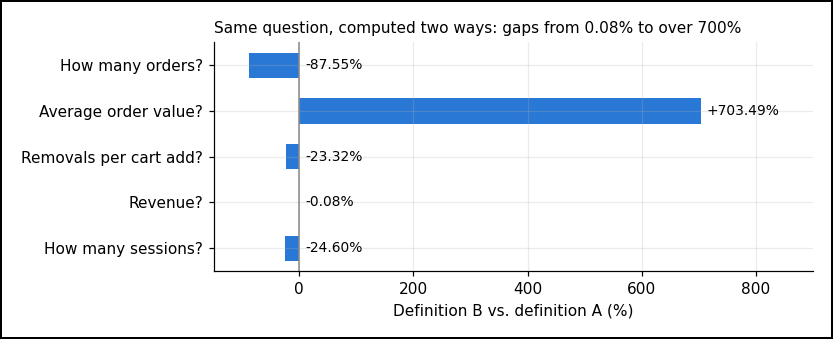

In [17]:
fig, ax = plt.subplots(figsize=(7.5, 3))
order = compare.iloc[::-1]
ax.barh(order["question"], order["B vs A %"], color=BLUE, height=0.55)
for y, v in enumerate(order["B vs A %"]):
    ax.text(max(v, 0) + 10, y, f"{v:+.2f}%", va="center", ha="left", fontsize=9)
ax.axvline(0, color=GREY, linewidth=1)
ax.set_xlim(-150, 900)
ax.set_xlabel("Definition B vs. definition A (%)")
ax.set_title("Same question, computed two ways: gaps from 0.08% to over 700%", fontsize=10, loc="left")
plt.tight_layout(); plt.show()

How to read each row ("B vs A %" = how much higher or lower B is than A):

- **Orders:** A = 125,823 purchase rows, B = 15,664 orders, −87.55%. A purchase row is one product line, not one order.
- **Average order value:** A = 4.97 per purchase row, B = 39.97 per order, +703.49%. An average order has 8.03 lines (Part 1d), so dividing by lines instead of orders makes the average about 8 times smaller.
- **Removals per cart add:** A = 0.678 raw, B = 0.520 after cleaning, −23.32%. The raw figure includes the extra copies. (Both figures rest on `remove_from_cart`, which is unreliable, Part 1a.)
- **Revenue:** A = 626,063 gross, B = 625,579 net, only −0.08%. The 14 refund candidates barely change a five-month total. Some definition choices matter a lot and some hardly at all; only computing both shows which.
- **Sessions:** A = 440,484 logged session ids, B = 332,144 sessions by the 30-minute rule, −24.60%. With 15 or 60 minutes the rule gives 349,832 or 319,034, both far below the logged count.

**Conclusion:** none of these ten numbers is an arithmetic mistake. When two dashboards disagree, they may simply use two definitions, as all five pairs here do. The semantic layer's job is to make each definition explicit and the same everywhere.

## Exercises

### Exercise 1 — Write the tracking-plan rules for a new event

The team is adding a checkout page and wants a "Checkout Started" event. Write its JSON Schema, then check it against two **payloads** (example events, as the website would send them): one that should pass and one that should fail. Both payloads are made up for this exercise.

**Worked answer:** the schema requires a `cart_id` (so the checkout can later be linked to its order, and checkouts that never become orders can be counted, with their `cart_value` as an upper-bound estimate of revenue at stake), an item count of at least 1 and a cart value above 0. Currency is optional and must be one of a list of codes; USD and EUR are chosen examples, since this log records no currency.

In [18]:
checkout_started = {
    "type": "object",
    "required": ["event_time", "user_id", "user_session", "cart_id", "items", "cart_value"],
    "properties": {
        "event_time": {"type": "string"},
        "user_id": {"type": "integer", "minimum": 1},
        "user_session": {"type": "string", "minLength": 1},
        "cart_id": {"type": "string", "minLength": 1},
        "items": {"type": "integer", "minimum": 1},
        "cart_value": {"type": "number", "exclusiveMinimum": 0},
        "currency": {"enum": ["USD", "EUR"]},  # chosen example codes: the log records no currency
    },
}
# Two made-up payloads, written for this drill (not from the data).
good = {"event_time": "2020-02-03 10:00:00", "user_id": 42, "user_session": "a1",
        "cart_id": "c9", "items": 3, "cart_value": 24.5, "currency": "USD"}
bad_payload = {"event_time": "2020-02-03 10:00:00", "user_id": 42, "user_session": "a1",
               "items": 0, "cart_value": 0}
v = jsonschema.Draft7Validator(checkout_started)
print("good payload errors:", [e.message for e in v.iter_errors(good)])
print("bad payload errors:")
for err in v.iter_errors(bad_payload):
    print("  -", err.message)

good payload errors: []
bad payload errors:
  - 'cart_id' is a required property
  - 0 is less than the minimum of 1
  - 0 is less than or equal to the minimum of 0


**Reading the result:** the good payload passes with no errors. The bad one breaks three rules: no `cart_id`, an item count of 0 and a cart value of 0. Each break is reported by name.

### Exercise 2 — Two dashboards disagree

**The question:** two dashboards both show December's "average order value". Dashboard A shows **4.98**. Dashboard B shows **37.12**. Which is right?

**Step 1: look up how each dashboard computes its number** (in practice: open each dashboard's query):
- A = revenue of all purchase rows in the raw log ÷ number of those rows
- B = revenue of clean purchase rows ÷ number of orders

**Step 2: recompute both from the data**, to confirm step 1:

In [19]:
dec = "substr(event_time, 1, 10) BETWEEN '2019-12-01' AND '2019-12-31'"
raw = query(con, f"SELECT COUNT(*) AS n, SUM(price) AS rev FROM events WHERE event_type = 'purchase' AND {dec}").iloc[0]
clean = query(con, f"SELECT COUNT(*) AS n, SUM(price) AS rev FROM events_clean WHERE event_type = 'purchase' AND {dec}").iloc[0]
n_orders = query(con, f"SELECT COUNT(*) AS n FROM orders WHERE {dec}")["n"][0]
print("December, counted from the data:")
print(f"  raw purchase rows          {int(raw['n']):>12,}")
print(f"  raw purchase revenue       {raw['rev']:>12,.2f}")
print(f"  clean purchase rows        {int(clean['n']):>12,}")
print(f"  clean purchase revenue     {clean['rev']:>12,.2f}")
print(f"  orders                     {int(n_orders):>12,}")
print()
print(f"A = {raw['rev']:,.2f} ÷ {int(raw['n']):,} = {raw['rev'] / raw['n']:.2f}")
print(f"B = {clean['rev']:,.2f} ÷ {int(n_orders):,} = {clean['rev'] / n_orders:.2f}")
print(f"lines per order = {int(clean['n']):,} ÷ {int(n_orders):,} = {clean['n'] / n_orders:.2f}")

December, counted from the data:
  raw purchase rows                21,657
  raw purchase revenue         107,848.05
  clean purchase rows              21,646
  clean purchase revenue       107,917.35
  orders                            2,907

A = 107,848.05 ÷ 21,657 = 4.98
B = 107,917.35 ÷ 2,907 = 37.12
lines per order = 21,646 ÷ 2,907 = 7.45


**Step 3: what it means.** A divides by product lines, B by orders. An order has 7.45 lines on average (21,646 clean purchase rows ÷ 2,907 orders). So A is revenue per line, not per order; B is the true average order value.

**The fix:** give the two metrics different names ("revenue per line" and "average order value") and define both once in the semantic layer.

## Key takeaways

- **Observation:** 5.23% of logged rows are extra copies, mostly cart removals (24.82% of removal rows). Purchases (0.06%) and views (0.01%) have almost none.
- **Conclusion:** the cause of the duplicates is unknown. Multi-unit removals are unlikely (duplicated removals come after 2+ adds less often than single ones: 5.28% vs. 11.87%); a logging error is not settled. Removing duplicates is Rule 1, a stated choice.
- **Observation:** even after removing duplicates, 11.41% of (user, product) pairs show a removal of a product that wasn't in the cart, so `remove_from_cart` is unreliable.
- **Conclusion:** the log has no order id, but orders rebuilt as "same user, session and second" (a grouping window of 0 seconds) hold up: widening the window to 60 seconds would merge only 20 of 15,664 orders.
- **Assumption:** the log has no quantity, so each purchase line counts as one unit. This can't be tested; revenue is therefore a minimum.
- **Observation:** the schema check passes 2,026,191 of 2,026,833 events but finds none of the extra copies. Checking one row at a time is not enough.
- **Hypothesis:** the 14 negative-price purchases are suspected refunds, and are treated as refunds. A refund event in the log would confirm it.
- **Conclusion:** the same question, computed two plausible ways, gives answers between 0.08% and 703.49% apart (Part 4). Writing each definition once, in a semantic layer, keeps later numbers comparable.
- **Carried forward:** every later module uses `events_clean`, `orders`, `daily_active` and `metrics.json`. The February zero-price jump is investigated in Module 10.